In [1]:
 # Task 1: Create Your Own Dataset
import pandas as pd
import numpy as np
# Creating dataset
data = {
    "Engine_Size": [1.0, 1.2, 1.5, 1.3, 1.6, 2.0, 1.8, 2.2, 1.4, 1.1,
                    1.7, 2.5, 1.9, 2.3, 1.2],
    "Mileage": [20, 18, 15, 19, 14, 12, 13, 10, 17, 21,
                16, 8, 11, 9, 22],
    "Age": [5, 4, 3, 6, 2, 1, 3, 1, 4, 7,
            2, 1, 2, 1, 6],
    "Car_Price": [5, 6, 8, 5.5, 9, 15, 12, 18, 7, 4,
                  10, 20, 14, 19, 4.5]
}
df = pd.DataFrame(data)
print(df)

    Engine_Size  Mileage  Age  Car_Price
0           1.0       20    5        5.0
1           1.2       18    4        6.0
2           1.5       15    3        8.0
3           1.3       19    6        5.5
4           1.6       14    2        9.0
5           2.0       12    1       15.0
6           1.8       13    3       12.0
7           2.2       10    1       18.0
8           1.4       17    4        7.0
9           1.1       21    7        4.0
10          1.7       16    2       10.0
11          2.5        8    1       20.0
12          1.9       11    2       14.0
13          2.3        9    1       19.0
14          1.2       22    6        4.5


In [2]:
 # Task 2: Data Exploration
# First 5 rows
print("First 5 Rows:\n", df.head())
# Last 5 rows
print("\nLast 5 Rows:\n", df.tail())
# Shape
print("\nDataset Shape:", df.shape)
# Data types
print("\nData Types:\n", df.dtypes)
# Missing values
print("\nMissing Values:\n", df.isnull().sum())

First 5 Rows:
    Engine_Size  Mileage  Age  Car_Price
0          1.0       20    5        5.0
1          1.2       18    4        6.0
2          1.5       15    3        8.0
3          1.3       19    6        5.5
4          1.6       14    2        9.0

Last 5 Rows:
     Engine_Size  Mileage  Age  Car_Price
10          1.7       16    2       10.0
11          2.5        8    1       20.0
12          1.9       11    2       14.0
13          2.3        9    1       19.0
14          1.2       22    6        4.5

Dataset Shape: (15, 4)

Data Types:
 Engine_Size    float64
Mileage          int64
Age              int64
Car_Price      float64
dtype: object

Missing Values:
 Engine_Size    0
Mileage        0
Age            0
Car_Price      0
dtype: int64


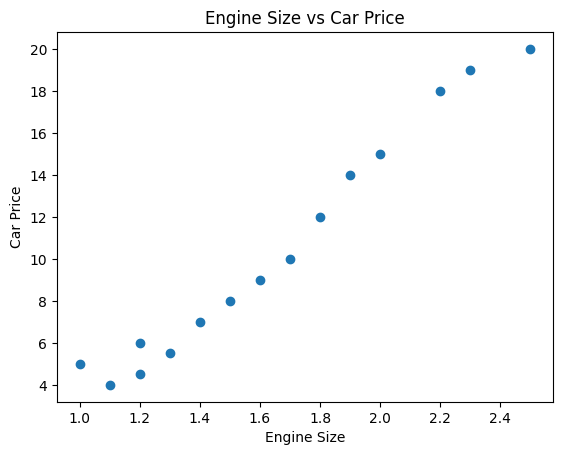

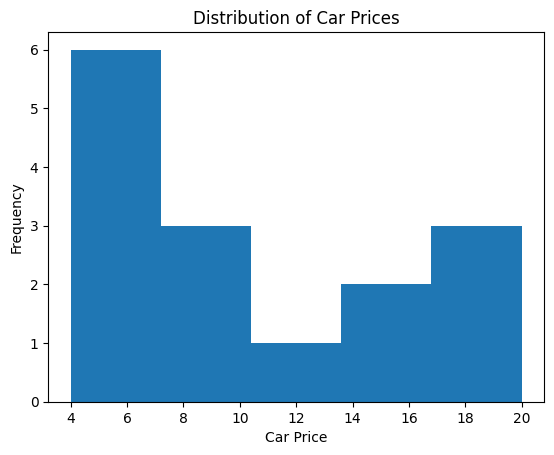

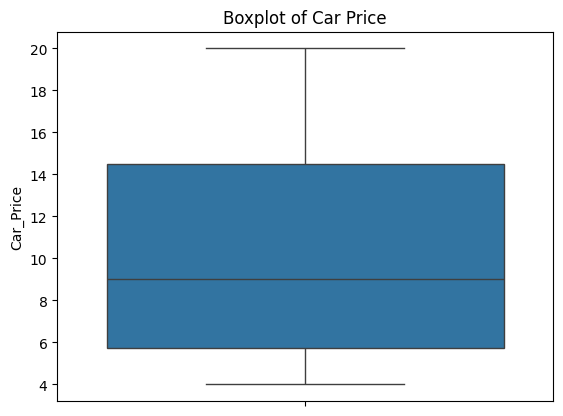

In [3]:
 # Task 3: Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Scatter Plot
plt.scatter(df["Engine_Size"], df["Car_Price"])
plt.title("Engine Size vs Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.show()
# Histogram
plt.hist(df["Car_Price"], bins=5)
plt.title("Distribution of Car Prices")
plt.xlabel("Car Price")
plt.ylabel("Frequency")
plt.show()
# Boxplot
sns.boxplot(y=df["Car_Price"])
plt.title("Boxplot of Car Price")
plt.show()

In [5]:
 # Task 4: Train Linear Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
# Features and target
X = df[["Engine_Size", "Mileage", "Age"]]
y = df["Car_Price"]
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Model training
model = LinearRegression()
model.fit(X_train, y_train)
# Prediction
y_pred = model.predict(X_test)
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("R2 Score:", r2)

MAE: 1.6761623990553425
R2 Score: 0.9297188059943973


**Explanation**

MAE shows the average prediction error in price.

R² score close to 1 means good model performance.

If R² > 0.8, the model explains most of the price variation.

Engine size likely has strong influence on price.

In [6]:
# Task 5: Feature Experiment
# Remove One Feature (Remove Age)

X1 = df[["Engine_Size", "Mileage"]]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train1, y_train1)

y_pred1 = model1.predict(X_test1)

print("R2 without Age:", r2_score(y_test1, y_pred1))

R2 without Age: 0.931756007105403


In [7]:
# Add New Feature (Power-to-Engine Ratio Example)
df["Price_per_Engine"] = df["Car_Price"] / df["Engine_Size"]

X2 = df[["Engine_Size", "Mileage", "Age", "Price_per_Engine"]]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("R2 with New Feature:", r2_score(y_test2, y_pred2))

R2 with New Feature: 0.9950266556194889


**Comparison:**

If R² decreases after removing Age → Age is important.

If R² increases after adding new feature → New feature improves prediction.

Feature with largest coefficient magnitude is more important.

In [8]:
# Task 6: Overfitting Check
#Train on Full Dataset (No Split)

model_full = LinearRegression()
model_full.fit(X, y)

y_full_pred = model_full.predict(X)

print("R2 on Full Dataset:", r2_score(y, y_full_pred))

R2 on Full Dataset: 0.9757882981219937


**Explanation of Overfitting:**

Overfitting happens when a model learns training data too well.

It performs very well on training data but poorly on unseen data.

R² on full dataset is usually higher.

Proper train-test split helps check real performance.